In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np
from shapely.geometry import Polygon, Point, LineString
from shapely.ops import unary_union



segments = 64 #line segments per quarter circle

RNG = np.random.default_rng()

def make_map(r = 1.0):
  return Point(0.0,0.0).buffer(r, quad_segs=segments)

def make_splat(domain, rng, n_wobble = 7, step = 0.22, wobble_scale = 0.28, smooth = 0.05):
  R = np.sqrt(domain.area / np.pi)
  center = [0.0, 0.0]
  pos = center + rng.normal(scale = 0.25 * R, size = 2)

  wobbles = []
  for w in range(n_wobble):
    r = wobble_scale * R * rng.uniform(0.6, 1.4)
    wobbles.append(Point(pos).buffer(r, quad_segs=segments))
    pos = pos + rng.normal(scale = step * R, size = 2)

  splat = unary_union(wobbles)

  splat = splat.buffer(smooth * R, quad_segs = segments).buffer(-smooth * R, quad_segs = segments)


  splat = splat.intersection(domain)

  return splat

def make_sun_constraint(r = 0.5):
  return Point(0.0,0.0).buffer(r, quad_segs=segments)

In [5]:
def make_sweep(angle, offset, width, domain):
  R = np.sqrt(domain.area / np.pi)
  # along track
  d = np.array([np.cos(angle), np.sin(angle)])
  #across track
  n = np.array([-np.sin(angle), np.cos(angle)])

  p0 = (offset * n) - (2 *R * d)
  p1 = (offset * n) + (2 *R * d)
  track = LineString([p0, p1])

  return track.buffer(width / 2.0, cap_style=2).intersection(domain)


In [6]:
def make_patches(ax, geom, **kw):
    if geom.geom_type.startswith("Multi"):
      geoms = geom.geoms
    else:
      geoms = [geom]
    for g in geoms:
        if g.is_empty:
            continue
        ax.add_patch(patches.Polygon(np.array(g.exterior.coords), **kw))
        for ring in g.interiors:
            ax.add_patch(patches.Polygon(np.array(ring.coords), facecolor="white", edgecolor="none"))

def plot_scene(domain, splat, sweeps, coverage, sun_constraint, overlap, path = "plot.png"):
  fig, ax = plt.subplots(figsize=(6.5, 6.5))

  make_patches(ax, domain, facecolor="#C4D8E2", edgecolor="black", linewidth=1.2)
  make_patches(ax, sun_constraint, facecolor="#FFDE21", edgecolor="#800000", linewidth=0.5)
  make_patches(ax, splat, facecolor="#50C878", edgecolor="#2C5F34", linewidth=1.5, alpha=0.8)
  make_patches(ax, coverage, facecolor="green", edgecolor="green", linewidth=1.5, alpha=0.8)
  make_patches(ax, overlap, facecolor="#F88379", edgecolor="#800000", linewidth=0.5, alpha=0.8)
  for s in sweeps:
    make_patches(ax, s, facecolor="#2b6cb0", edgecolor="none", alpha=0.30)


  R = np.sqrt(domain.area / np.pi)
  ax.set_xlim(-1.1 * R, 1.1 * R)
  ax.set_ylim(-1.1 * R, 1.1 * R)
  ax.set_aspect("equal")
  ax.axis("off")

  fig.savefig(path, dpi=150, bbox_inches="tight")
  plt.show()
  return path

In [21]:
def coverage_report(splat, sweeps, constraints, domain):
    
    constraint = unary_union(constraints)
    union = unary_union(sweeps)
    splat = splat.difference(constraint)
    coverage = union.intersection(splat)
    report = {
        "splat_area": splat.area,
        "domain_area": domain.area,
        "swath_area_on_map": union.area,
        "covered_area": coverage.area,
        "coverage_fraction": coverage.area / splat.area if splat.area else 0.0,
        "wasted_area": union.area - coverage.area,
        "efficiency": coverage.area / union.area if union.area else 0.0,
        }
    remaining = splat
    order = []
    pool = list(enumerate(sweeps))
    while pool:
        best_i, best_geom, best_gain = None, None, -1.0
        for i, s in pool:
            gain = remaining.intersection(s).area
            if gain > best_gain:
                best_i, best_geom, best_gain = i, s, gain
        order.append((best_i, best_gain))
        remaining = remaining.difference(best_geom)
        pool = [(i, s) for i, s in pool if i != best_i]
    report["greedy_order"] = order
    report["uncovered_area"] = remaining.area
    return report
  

{'splat_area': 1.3687986893577924, 'domain_area': 3.1412772509327747, 'swath_area_on_map': 1.8839212615751393, 'covered_area': 0.6965333861362746, 'coverage_fraction': 0.5088647377819097, 'wasted_area': 1.1873878754388647, 'efficiency': 0.36972531726400587, 'greedy_order': [(0, 0.36775797148456835), (1, 0.3662732206375334), (3, 0.20768273271100504), (2, 0.061120477661901554)], 'uncovered_area': 0.36596428686277993}


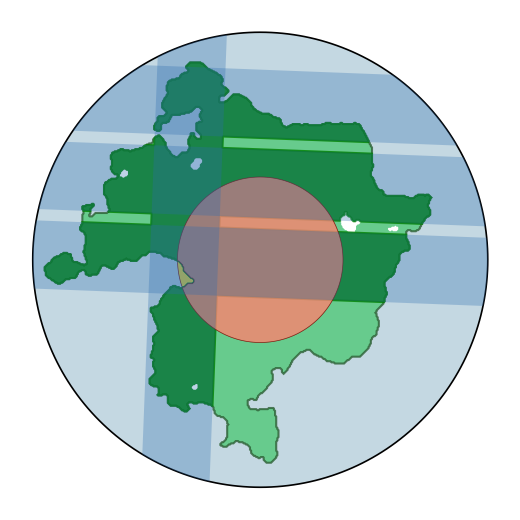

'plot.png'

In [10]:
from perlin import make_perlin_splat
domain = make_map(1.0)

splat = make_perlin_splat(domain, RNG)
#splat2 = make_splat(domain, RNG)
#splat = splat.union(splat2)

sun_constraint = make_sun_constraint(RNG.uniform(0.2,0.5))

rand_angle = RNG.uniform(0, 180)
rand_offset = RNG.uniform(-0.5, 0.5)
sweep = make_sweep(np.deg2rad(rand_angle), rand_offset, 0.3, domain)
sweep2 = make_sweep(np.deg2rad(rand_angle), rand_offset+0.35, 0.3, domain)
sweep3 = make_sweep(np.deg2rad(rand_angle), rand_offset-0.35, 0.3, domain)
sweep4 = make_sweep(np.deg2rad(rand_angle+90), rand_offset, 0.3, domain)
sweeps = [sweep, sweep2, sweep3, sweep4]

overlap = splat.intersection(unary_union(sweeps))

sun_overlap = splat.intersection(sun_constraint)
report = coverage_report(splat, sweeps, sun_constraint, domain)
print(report)

plot_scene(domain, splat, sweeps, overlap, sun_constraint, sun_overlap)

Greedy: 53.44631968553307 %
DE results: 55.62414421447497 %


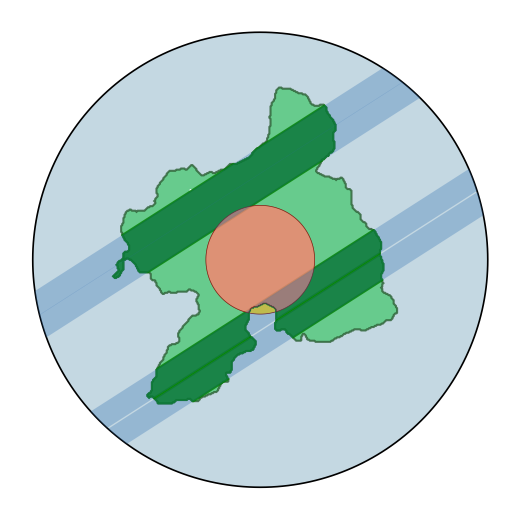

'plot.png'

In [28]:
import numpy as np
from scipy import optimize

# get coverage fraction from vector of parallel sweeps
def coverage_of(x, splat, domain, width, constraints):
    theta = x[0]
    offsets = x[1:]
    sweeps = [make_sweep(theta, o, width, domain) for o in offsets]
    return coverage_report(splat, sweeps, constraints, domain)["coverage_fraction"]

def greedy_seed(splat, domain, n_passes, width, constraints, n_angles=12, n_offsets=41):
    # make grid of angles and offests
    R = np.sqrt(domain.area / np.pi)
    angles = np.linspace(0, np.pi, n_angles, endpoint=False)
    offset_grid = np.linspace(-R, R, n_offsets)

    best_vector, best_cov = None, -1.0
    for theta in angles:
        chosen = []
        remaining = splat
        for i in range(n_passes):
            gains = []

            for offset in offset_grid:
                sweep = make_sweep(theta, offset, width, domain)
                gains.append(remaining.intersection(sweep).area)

            offset_best = offset_grid[np.argmax(gains)]
            chosen.append(offset_best)

            remaining = remaining.difference(
                make_sweep(theta, offset_best, width, domain))
            
        vector = np.array([theta, *chosen])
        cov = coverage_of(vector, splat, domain, width, constraints)
        if cov > best_cov:
            best_vector, best_cov = vector, cov

    return best_vector, best_cov

def objective(x, splat, domain, width, constraints):
    return -coverage_of(x,splat, domain, width, constraints)


domain = make_map(1.0)
splat = make_perlin_splat(domain, RNG)
sun_constraint = make_sun_constraint(RNG.uniform(0.2,0.5))
constraints = [sun_constraint]

R = np.sqrt(domain.area/np.pi)
width = 0.1
K = 4 # number of passes/offsets
bounds = [(0,np.pi)] + [(-R,R)] * K



greedy_vector, greedy_coverage = greedy_seed(splat, domain, K, width, constraints, n_angles=12, n_offsets=41)


result = optimize.differential_evolution(
    objective,
    bounds,
    args = [splat, domain, width, constraints],
    x0 = greedy_vector,
    popsize = 12,
    maxiter = 40,
    rng = 0,
    polish= False

)

best_vector = result.x
best_coverage = -result.fun
print("Greedy:",  greedy_coverage*100, "%")
print("DE results:", best_coverage*100, "%")


sweeps = []
for sweep in range(K):
    sweeps.append(make_sweep(best_vector[0], best_vector[sweep + 1], width, domain))

sun_overlap = splat.intersection(sun_constraint)
overlap = splat.intersection(unary_union(sweeps))
plot_scene(domain, splat, sweeps, overlap, sun_constraint, sun_overlap)

        


